<a href="https://colab.research.google.com/github/rotoncsedu/Computer-Vision/blob/main/Fine_Tuning_of_VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mdalimranroton","key":"77970a92a73d89c8164499b9d653fd8b"}'}

In [13]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [14]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:02<00:00, 287MB/s]



In [15]:
import os
import shutil
import random
from PIL import Image
import tensorflow as tf

# Paths
SOURCE_DIR = "/content/PetImages"
BASE_DIR = "/content/data"

# Split ratios
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

classes = ["Cat", "Dog"]

# Function to check valid images
def is_valid_image(path):
    try:
        img = Image.open(path)
        img.verify()  # check corruption
        return True
    except:
        return False

# Create folders
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(BASE_DIR, split, cls), exist_ok=True)

# Split files
for cls in classes:
    cls_path = os.path.join(SOURCE_DIR, cls)
    all_files = os.listdir(cls_path)

    valid_files = []

    # Validate images properly
    for f in all_files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            full_path = os.path.join(cls_path, f)
            if is_valid_image(full_path):
                valid_files.append(f)

    print(f"{cls}: {len(valid_files)} valid images")

    random.shuffle(valid_files)

    total = len(valid_files)
    train_end = int(train_ratio * total)
    val_end = int((train_ratio + val_ratio) * total)

    train_files = valid_files[:train_end]
    val_files = valid_files[train_end:val_end]
    test_files = valid_files[val_end:]

    # Copy files
    for f in train_files:
        shutil.copy(os.path.join(cls_path, f),
                    os.path.join(BASE_DIR, "train", cls, f))

    for f in val_files:
        shutil.copy(os.path.join(cls_path, f),
                    os.path.join(BASE_DIR, "val", cls, f))

    for f in test_files:
        shutil.copy(os.path.join(cls_path, f),
                    os.path.join(BASE_DIR, "test", cls, f))

print("Dataset split complete!")

Cat: 12499 valid images


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Dog: 12499 valid images
Dataset split complete!


In [16]:
import os

BASE_DIR = "/content/data"

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()} SET:")
    total = 0

    for cls in ["Cat", "Dog"]:
        path = os.path.join(BASE_DIR, split, cls)
        count = len(os.listdir(path))
        total += count
        print(f"{cls}: {count}")

    print(f"Total: {total}")


TRAIN SET:
Cat: 11739
Dog: 11700
Total: 23439

VAL SET:
Cat: 6111
Dog: 6104
Total: 12215

TEST SET:
Cat: 6146
Dog: 6066
Total: 12212


In [17]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data/train",
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data/val",
    image_size=(128, 128),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data/test",
    image_size=(128, 128),
    batch_size=32
)

Found 23439 files belonging to 2 classes.
Found 12215 files belonging to 2 classes.
Found 12212 files belonging to 2 classes.


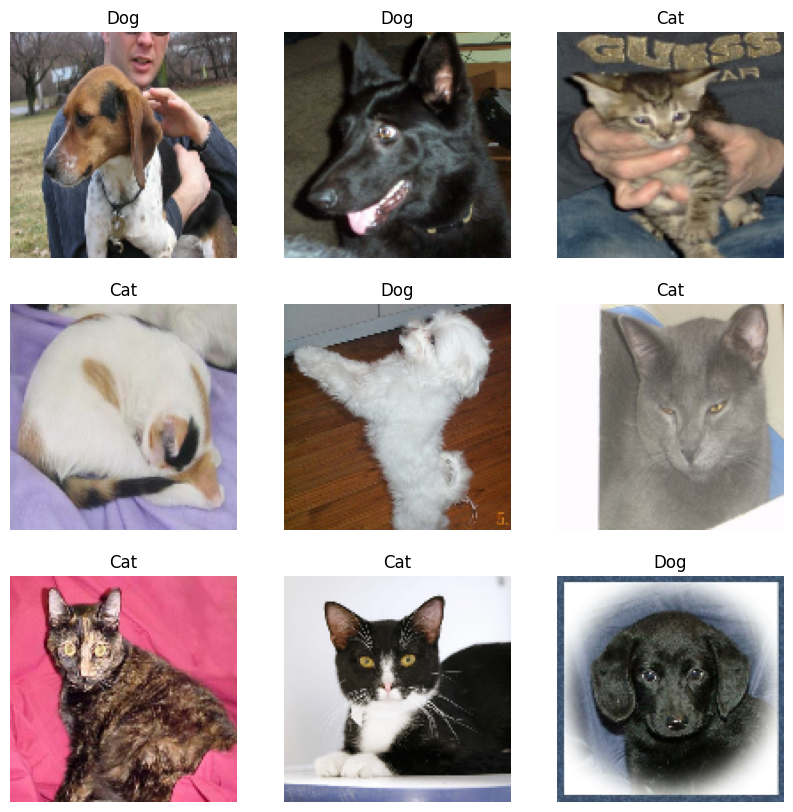

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

class_names = test_ds.class_names # Define class_names here

for images, labels in test_ds.take(1):
    for i in range(9):  # show 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [20]:
## Installing the VGG16

In [21]:
from tensorflow import keras
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [23]:
from tensorflow import keras
from tensorflow.keras import layers
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

In [24]:
from tensorflow import keras
inputs = keras.Input(shape=(128, 128, 3))

x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)

x = conv_base(x)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

In [25]:
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

In [26]:
history = model.fit(
    train_ds.ignore_errors(),
    epochs=10,
    validation_data=val_ds.ignore_errors(),
    callbacks=callbacks
)

Epoch 1/10
    726/Unknown 51s 62ms/step - accuracy: 0.8123 - loss: 0.6776

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


726/726 ━━━━━━━━━━━━━━━━━━━━ 73s 92ms/step - accuracy: 0.8769 - loss: 0.3544 - val_accuracy: 0.9496 - val_loss: 0.1413
Epoch 2/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 65s 90ms/step - accuracy: 0.9372 - loss: 0.1573 - val_accuracy: 0.9609 - val_loss: 0.1066
Epoch 3/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 65s 90ms/step - accuracy: 0.9477 - loss: 0.1371 - val_accuracy: 0.9658 - val_loss: 0.0950
Epoch 4/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 142s 173ms/step - accuracy: 0.9535 - loss: 0.1186 - val_accuracy: 0.9690 - val_loss: 0.0844
Epoch 5/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 65s 89ms/step - accuracy: 0.9584 - loss: 0.1097 - val_accuracy: 0.9732 - val_loss: 0.0772
Epoch 6/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 65s 90ms/step - accuracy: 0.9619 - loss: 0.1031 - val_accuracy: 0.9707 - val_loss: 0.0870
Epoch 7/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 65s 90ms/step - accuracy: 0.9645 - loss: 0.0967 - val_accuracy: 0.9800 - val_loss: 0.0642
Epoch 8/10
726/726 ━━━━━━━━━━━━━━━━━━━━ 65s 90ms/step - accuracy: 0.9664 - loss: 0.0908 - val_accur

In [27]:
model = keras.models.load_model("convnet_from_scratch_with_augmentation.keras")
test_loss, test_acc = model.evaluate(test_ds.ignore_errors())
print(f"Test accuracy: {test_acc:.3f}")

378/378 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.9844 - loss: 0.0537
Test accuracy: 0.984


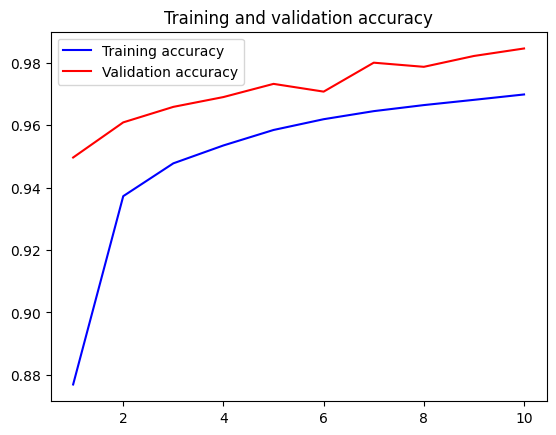

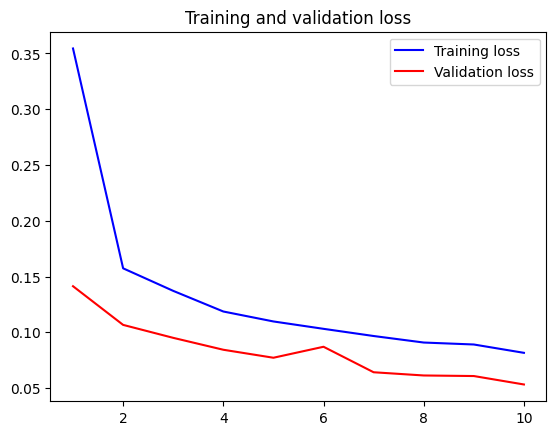

In [28]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy)+1)
plt.plot(epochs, accuracy, "b", label="Training accuracy")
plt.plot(epochs, val_accuracy, "r", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "b", label="Training loss")
plt.plot(epochs, val_loss, "r", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()